In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

data = pd.read_csv('icbhi_dataset.csv')

X = data.iloc[:, :-2]   # mfcc features
y = data['crackle']     # choose one target (numerical)

# A1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_1 = X_train.iloc[:, [0]]  
X_test_1 = X_test.iloc[:, [0]]

reg = LinearRegression().fit(X_train_1, y_train)

y_train_pred = reg.predict(X_train_1)
y_test_pred = reg.predict(X_test_1)


In [8]:
#A2 
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mape, r2

train_metrics = evaluate(y_train, y_train_pred)
test_metrics = evaluate(y_test, y_test_pred)

print("Train:", train_metrics)
print("Test:", test_metrics)


Train: (0.21979053293711653, np.float64(0.4688182301672115), np.float64(inf), 0.019749518425214108)
Test: (0.22973575215690872, np.float64(0.47930757573494365), np.float64(inf), 0.0030585177939279617)


In [9]:
#A3
reg_all = LinearRegression().fit(X_train, y_train)

y_train_pred_all = reg_all.predict(X_train)
y_test_pred_all = reg_all.predict(X_test)

print("Train:", evaluate(y_train, y_train_pred_all))
print("Test:", evaluate(y_test, y_test_pred_all))


Train: (0.20636268953602105, np.float64(0.4542716032683763), np.float64(inf), 0.07963676554427268)
Test: (0.21726593046444165, np.float64(0.46611793621833697), np.float64(inf), 0.05717148194607602)


In [10]:
#A4
X_cluster = X_train.copy()

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X_cluster)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

print("Cluster Centers:\n", centers)


Cluster Centers:
 [[-337.96511718  125.47758836   50.17035526   35.05200517   25.31042855
    23.83186703   18.79339562   15.51872502   12.03550202    9.89371385
     8.42256452    8.73381964    8.23209695]
 [-521.6121304   109.4901537    57.90551438   34.73693771   24.69253016
    24.09424603   22.12369362   19.12490496   14.29397707   10.97998483
     9.85747359   10.12991002    9.68053942]]


In [11]:
#A5
sil = silhouette_score(X_cluster, labels)
ch = calinski_harabasz_score(X_cluster, labels)
db = davies_bouldin_score(X_cluster, labels)

print("Silhouette:", sil)
print("CH Score:", ch)
print("DB Index:", db)


Silhouette: 0.5048984710803689
CH Score: 8030.401906084246
DB Index: 0.7262623426528341


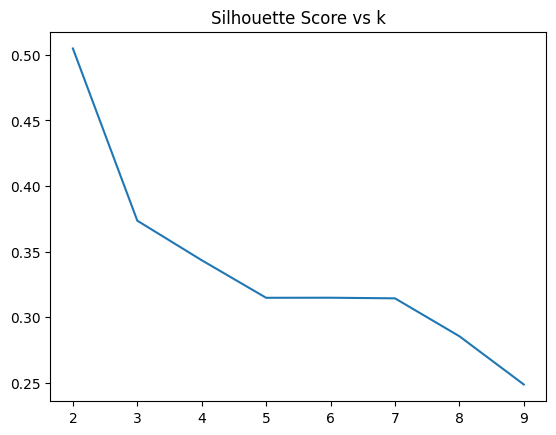

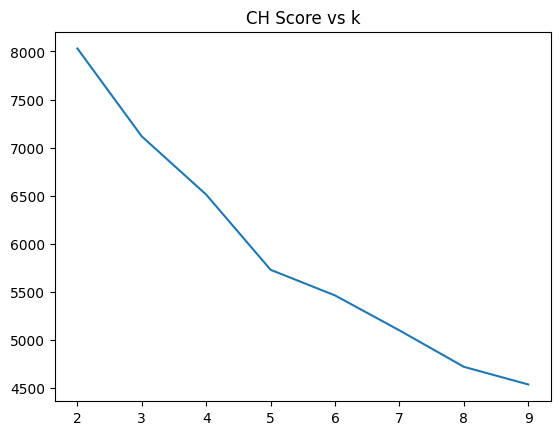

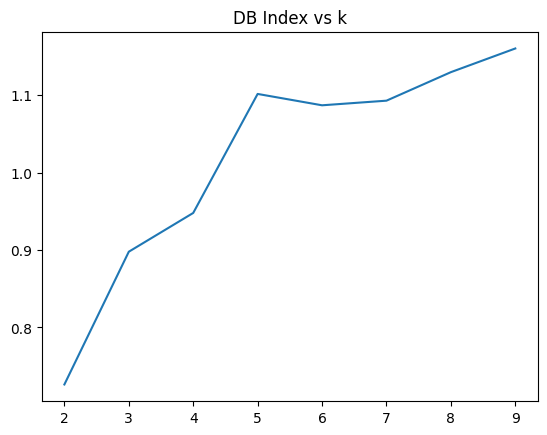

In [17]:
# A6
k_values = range(2, 10)

sil_scores = []
ch_scores = []
db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X_cluster)
    labels = kmeans.labels_
    
    sil_scores.append(silhouette_score(X_cluster, labels))
    ch_scores.append(calinski_harabasz_score(X_cluster, labels))
    db_scores.append(davies_bouldin_score(X_cluster, labels))
    
plt.figure()
plt.plot(k_values, sil_scores)
plt.title("Silhouette Score vs k")
plt.show()

plt.figure()
plt.plot(k_values, ch_scores)
plt.title("CH Score vs k")
plt.show()

plt.figure()
plt.plot(k_values, db_scores)
plt.title("DB Index vs k")
plt.show()


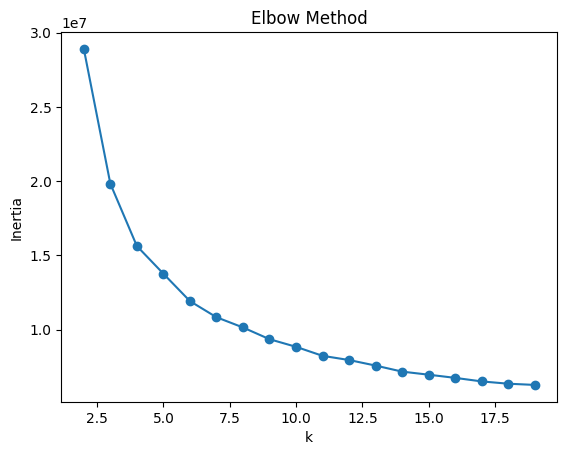

In [16]:
# A7
distortions = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X_cluster)
    distortions.append(kmeans.inertia_)

plt.plot(range(2,20), distortions, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()
